# Plot map of S-MODE IOP-2 Sampling
### Shailja Gangrade

In [1]:
import numpy as np
import xarray as xr
import matplotlib.pyplot as plt
from datetime import datetime, timedelta
import pandas as pd
import scipy 
import scipy.io as sio
from scipy import stats
import cartopy.crs as ccrs
import cartopy.feature as cfeature
import cmocean
import matplotlib.colors as colors
import matplotlib.ticker as ticker
import matplotlib.cm as cm

from mpl_toolkits.axes_grid1 import make_axes_locatable

In [2]:
## Load 16S sample metadata
metadata16S = pd.read_csv('IOP1_IOP2_16S_METADATA_FULL_11May2026.csv')
# print(metadata16S)
## Load bottle sample data
btl_IOP2 = pd.read_csv('IOP2-surface-bottledata-with-TSG.csv')
#print(btl_IOP2)

## Select only rows where 'year' is 2023 (IOP-2)
metadata16S_IOP2 = metadata16S[metadata16S['year'] == 2023] 
metadata16S_IOP2 = metadata16S_IOP2.reset_index(drop=True)
#print(metadata16S_IOP2)

## Select only rows where 'day' is April 18 thru 23 (IOP-2 eddy sampling only)
## Right now, only selecting bottle samples from flow-through ('niskin' == 0)
metadata16S_eddy = metadata16S_IOP2[(metadata16S_IOP2['day'] > 18) & (metadata16S_IOP2['day'] < 25) & (metadata16S_IOP2['niskin'] == 0)]
metadata16S_eddy = metadata16S_eddy.reset_index(drop=True)
#print(metadata16S_eddy)

# Now, we extract the station lons and lats for intializing the particles
stn_lats, stn_lons = metadata16S_eddy.lat, metadata16S_eddy.lon
btlstn_lats, btlstn_lons = btl_IOP2.latitude, btl_IOP2.longitude

## Reformat dates
# date_array = metadata16S_eddy.UTCDatetime.astype(str).to_list()
date_array = metadata16S_eddy.UTCDatetime.astype(str).to_list()
date_array_btl = btl_IOP2.date_dt.astype(str).to_list()

#print(date_array)

## Reformat dates from 16S metadata
original_format = "%d-%b-%Y %H:%M:%S"
# original_format = "%m/%d/%Y %H:%M:%S"
new_format = "%Y-%m-%d"

stn_dates = []
for date_str in date_array:
    datetime_obj = datetime.strptime(date_str, original_format)
    datetime_obj = datetime_obj.strftime(new_format)
    stn_dates.append(datetime_obj)

## Now, we have the station sampling dates for intializing the particles
#print(stn_dates)

## Reformat dates from Bottle Data metadata
original_format_btl = "%d-%b-%Y"
new_format_btl = "%Y-%m-%d"

btl_stn_dates = []
for date_str in date_array_btl:
    datetime_obj = datetime.strptime(date_str, original_format_btl)
    datetime_obj = datetime_obj.strftime(new_format_btl)
    btl_stn_dates.append(datetime_obj)

## Now, we have the station sampling dates for intializing the particles
print(stn_dates)
print(btl_stn_dates)

['2023-04-19', '2023-04-20', '2023-04-20', '2023-04-20', '2023-04-20', '2023-04-20', '2023-04-20', '2023-04-20', '2023-04-20', '2023-04-20', '2023-04-21', '2023-04-21', '2023-04-21', '2023-04-21', '2023-04-21', '2023-04-21', '2023-04-21', '2023-04-22', '2023-04-22', '2023-04-22', '2023-04-22', '2023-04-22', '2023-04-22', '2023-04-22', '2023-04-22', '2023-04-22', '2023-04-22']
['2023-04-11', '2023-04-11', '2023-04-11', '2023-04-11', '2023-04-11', '2023-04-11', '2023-04-11', '2023-04-11', '2023-04-11', '2023-04-11', '2023-04-11', '2023-04-12', '2023-04-12', '2023-04-12', '2023-04-12', '2023-04-12', '2023-04-12', '2023-04-12', '2023-04-12', '2023-04-12', '2023-04-12', '2023-04-12', '2023-04-12', '2023-04-12', '2023-04-12', '2023-04-12', '2023-04-12', '2023-04-12', '2023-04-12', '2023-04-12', '2023-04-12', '2023-04-12', '2023-04-12', '2023-04-12', '2023-04-12', '2023-04-12', '2023-04-12', '2023-04-12', '2023-04-12', '2023-04-12', '2023-04-12', '2023-04-12', '2023-04-12', '2023-04-12', '202

In [3]:
# Load chl-a

## Sentinel Chl OC4ME data from EUMETSAT (see eumdac_sentinel3_data.m script)
chl = xr.open_dataset('sentinel3_Apr19/chl_oc4me.nc').CHL_OC4ME
lon_chl = xr.open_dataset('sentinel3_Apr19/geo_coordinates.nc').longitude
lat_chl = xr.open_dataset('sentinel3_Apr19/geo_coordinates.nc').latitude

## Load Pacific Coastline
mat = scipy.io.loadmat('WorldCstLinePacific.mat')['cst']
clat,clon = mat['lat'][0][0], mat['lon'][0][0]

In [4]:
## Load CalCOFI station data
calcofi_data = pd.read_csv('CalCOFI_nutrient_data_surface_updatedMay2026.csv')
cc_lats, cc_lons = calcofi_data.lat, calcofi_data.lon
# cc_uniqlats, cc_uniqlons = np.unique(cc_lats), np.unique(cc_lons)
# len(cc_uniqlats), len(cc_uniqlons)

# len(cc_lats), len(cc_lons)

In [5]:
# Remove center 'white' color value from diverging color map and save new color map.

# Get original cmocean diverging colormap
orig_cmap = cmocean.cm.delta

# Extract color values (256 samples)
extracted_colors = orig_cmap(np.linspace(0, 1, 256))

# Define how much of the white center to cut out (e.g., skip index 118 to 138)
    # Lower number removes more from the start side, higher number from the end side of the center
lower_end = 115
upper_end = 141
new_colors = np.vstack((extracted_colors[:lower_end], extracted_colors[upper_end:]))

# Create the new custom colormap
no_white_cmap = colors.LinearSegmentedColormap.from_list(
    "delta_no_white", new_colors)

#####################################################
# Define your limits and desired pivot/center point
vmin, vmax = 1e-1, 30
pivot_point = 12.2  # Where the center/neutral color of the colormap should land. If you change vmin/vmax, you need to tune this value.

# Crop the already modified cmocean colormap using your pivot point
# diverging_cmap = cmocean.cm.curl  # or delta, balance, etc.
adjusted_no_white_cmap = cmocean.tools.crop(no_white_cmap, vmin, vmax, pivot=pivot_point)

# Apply LogNorm with matching vmin and vmax
log_norm = colors.LogNorm(vmin=vmin, vmax=vmax)

# Sample code to plot the data
# fig, ax = plt.subplots()
# mappable = ax.pcolormesh(data, cmap=adjusted_cmap, norm=log_norm)
# fig.colorbar(mappable, ax=ax)
# plt.show()

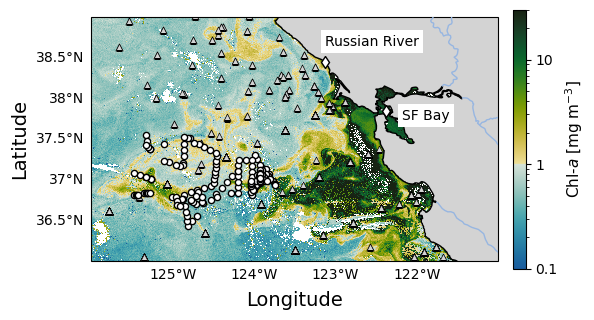

In [7]:
## Plot chl (natural units, but with log scale colorbar) on map with Bottle Sampling Locations and CalCOFI stations

# Load a cmocean colormap
cmoce_cmap = cmocean.cm.speed

# Set up map projection (US West Coast)
# fig = plt.figure(figsize=(8, 10))
fig = plt.figure()
ax = plt.axes(projection=ccrs.PlateCarree())
## Identify axes extents.
lonmin,lonmax,latmin,latmax = -126,-121,36,39
ax.set_extent([lonmin, lonmax, latmin, latmax], crs=ccrs.PlateCarree())

# Add geographic land and coastline layers
ax.add_feature(cfeature.LAND, facecolor='lightgray', zorder=2)
ax.add_feature(cfeature.COASTLINE, linewidth=1, zorder=3)
ax.add_feature(cfeature.RIVERS, linewidth=1, zorder=4)
# ax.add_feature(cfeature.STATES, linewidth=0.5, edgecolor='gray', zorder=3) # enable if showing more than just California land.

# Plot natural-unit Chl data using LogNorm (10^-2 to 10^1)
pcm = ax.pcolormesh(
    lon_chl, lat_chl, 10**chl,
    # norm=colors.LogNorm(vmin=1e-1, vmax=10**1.5),
    # cmap=no_white_cmap,
    cmap = adjusted_no_white_cmap,
    norm = log_norm,
    transform=ccrs.PlateCarree(),
    zorder=1
)

# Plot CalCOFI station locations
cc_stns = ax.scatter(cc_lons,cc_lats,s=25,c="lightgrey",edgecolors = "black",lw=0.5,marker='^') # try grey instead of lightgrey

# Plot bottle sampling locations.
stns = ax.scatter(btl_IOP2.longitude,btl_IOP2.latitude,s=20, c="white",edgecolors = "black")

## Add ROI locations (Russian River and SF Bay)
RR = [38.450159, -123.130602] # Russian River
SF = [37.840524, -122.379691] # SF Bay
CM = [40.438594, -124.413537] # Cape Mendocino

box_props = dict(boxstyle='square', facecolor='white', edgecolor='none') ##white box behind text labels

ax.plot(RR[1],RR[0],'dw', markeredgecolor = 'k',transform=ccrs.PlateCarree(),zorder=5);
ax.text(RR[1],RR[0]+0.2,'Russian River',fontsize=10, bbox=box_props, transform=ccrs.PlateCarree(), zorder=5)
ax.plot(SF[1],SF[0],'dw', markeredgecolor = 'k', transform=ccrs.PlateCarree(), zorder=5);
ax.text(SF[1]+0.2,SF[0]-0.1,'SF Bay',fontsize=10, bbox=box_props, transform=ccrs.PlateCarree(), zorder=5)
# ax.plot(CM[1],CM[0],'dk'); ax.text(CM[1]+0.1,CM[0]-0.15,'Cape Mendocino',fontsize=10)

# Add colorbar with log-scale ticks automatically derived from LogNorm
cbar = plt.colorbar(pcm, ax=ax, orientation='vertical', pad=0.03, shrink=0.7)
cbar.set_label(r'Chl-$a$ [$\mathrm{mg\ m^{-3}}$]', fontsize=11)
cbar.ax.yaxis.set_major_formatter(ticker.FormatStrFormatter('%g')) # Changes 10^x labeling to natural values.

# Gridlines and labels
gl = ax.gridlines(draw_labels=True, color='none', linestyle='None')
gl.top_labels = False; gl.right_labels = False

# Label for the bottom X-axis
ax.text(0.5, -0.2, 'Longitude', va='bottom', ha='center',
        rotation='horizontal', transform=ax.transAxes, fontsize=14)
# Label for the left Y-axis
ax.text(-0.2, 0.5, 'Latitude', va='center', ha='left',
        rotation='vertical', transform=ax.transAxes, fontsize=14)

plt.show()

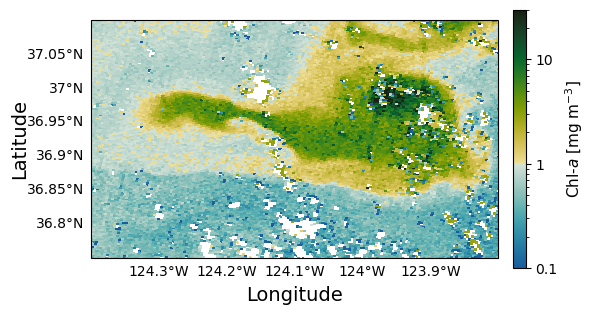

In [8]:
## Plot eddy zoomed in - natural units, log scale color bar.

# Set up map projection (US West Coast)
# fig = plt.figure(figsize=(8, 10))
fig = plt.figure()
ax = plt.axes(projection=ccrs.PlateCarree())
## Identify axes extents.
lonmin,lonmax,latmin,latmax = -124.4,-123.8,36.75,37.1
ax.set_extent([lonmin, lonmax, latmin, latmax], crs=ccrs.PlateCarree())

# Add geographic land and coastline layers
ax.add_feature(cfeature.LAND, facecolor='lightgray', zorder=2)
ax.add_feature(cfeature.COASTLINE, linewidth=1, zorder=3)
# ax.add_feature(cfeature.RIVERS, linewidth=1, zorder=4)
# ax.add_feature(cfeature.STATES, linewidth=0.5, edgecolor='gray', zorder=3) # enable if showing more than just California land.

# Plot natural-unit Chl data using LogNorm (10^-2 to 10^1)
pcm = ax.pcolormesh(
    lon_chl, lat_chl, 10**chl,
    # norm=colors.LogNorm(vmin=1e-1, vmax=10**1.5),
    # cmap=no_white_cmap,
    cmap = adjusted_no_white_cmap,
    norm = log_norm,
    transform=ccrs.PlateCarree(),
    zorder=1
)
# Add colorbar with log-scale ticks automatically derived from LogNorm
cbar = plt.colorbar(pcm, ax=ax, orientation='vertical', pad=0.03, shrink=0.7)
cbar.set_label(r'Chl-$a$ [$\mathrm{mg\ m^{-3}}$]', fontsize=11)
cbar.ax.yaxis.set_major_formatter(ticker.FormatStrFormatter('%g')) # Changes 10^x labeling to natural values.

# Gridlines and labels
gl = ax.gridlines(draw_labels=True, color='none', linestyle='None')
gl.top_labels = False; gl.right_labels = False

# Label for the bottom X-axis
ax.text(0.5, -0.2, 'Longitude', va='bottom', ha='center',
        rotation='horizontal', transform=ax.transAxes, fontsize=14)
# Label for the left Y-axis
ax.text(-0.2, 0.5, 'Latitude', va='center', ha='left',
        rotation='vertical', transform=ax.transAxes, fontsize=14)

plt.show()